In [1]:
from mainfunc import *
from Utils.plotting_functions import *
from Worlds.World import World
import Drone.Simulation

parameters = load_parameters("Settings/simulation_parameters.yaml")
init_state = create_initial_state()
thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

In [6]:
waypoints = [
    {"x": 0, "y": 0, "z": 0, "v": 5},
    {"x": 50, "y": 0, "z": 50, "v": 5},
    {"x": 1000, "y": 1000, "z": 10, "v": 5},
]

In [7]:
sim = Simulation(
    drone,
    world,
    waypoints, 
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=True,
    noise_annoyance_radius=9,
)
sim.startSimulation(stop_at_target=True, use_static_target=True, verbose=True)
costs = calculate_costs(sim, parameters['simulation_time'])
print(f"Total costs: {costs}")

Simulation completed in 12.50 seconds.
Total costs: {'total_cost': 2030.3115466379304, 'time_cost': 70, 'final_distance_cost': 298.6470663857602, 'oscillation_cost': 5.383678603379852, 'completition_cost': 333.33333333333337, 'overshoot_cost': 1198.5400581968006, 'power_cost': 76.34914520263672, 'noise_cost': 48.05826491601964, 'n_waypoints_completed': 2, 'tot_waypoints': 3}


KeyError: 0

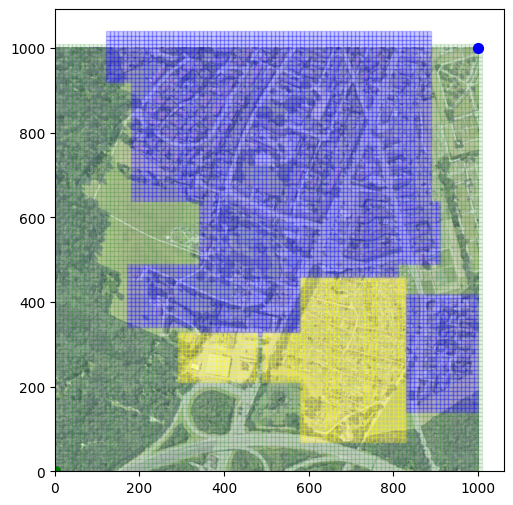

In [8]:
show2DWorld(
    world, [sim.positions], [waypoints[0]], [waypoints[-1]], [waypoints])
